# Task 2 — EDA + Baseline Only

Scope:
1. **EDA**: label distributions (Emotion, Offensive, Hate) + n-gram analysis.
2. **Baseline model**: AraBERT embeddings (mean-pooled, full dataset, batched) → Logistic Regression, one per label, with accuracy/F1/confusion matrix.

No fine-tuning, no advanced models — just enough to get a benchmark number to beat later.

In [1]:
!pip install arabert farasapy transformers scikit-learn nltk arabic-reshaper python-bidi -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 4.6 MB/s eta 0:00:00


In [2]:
import re
import unicodedata
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModel
from arabert.preprocess import ArabertPreprocessor
import arabic_reshaper
from bidi.algorithm import get_display

nltk.download('stopwords', quiet=True)
arabic_stopwords = list(stopwords.words('arabic'))

In [4]:
df = pd.read_csv("train.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         5960 non-null   int64 
 1   text       5960 non-null   object
 2   Emotion    5960 non-null   object
 3   Offensive  5960 non-null   object
 4   Hate       1744 non-null   object
dtypes: int64(1), object(4)
memory usage: 232.9+ KB


## 1. EDA — Label Distributions


--- Emotion ---
Emotion
anger           1551
disgust          777
neutral          661
love             593
joy              533
anticipation     491
optimism         419
sadness          335
confidence       210
pessimism        194
surprise         143
fear              53
Name: count, dtype: int64
Emotion
anger           26.02
disgust         13.04
neutral         11.09
love             9.95
joy              8.94
anticipation     8.24
optimism         7.03
sadness          5.62
confidence       3.52
pessimism        3.26
surprise         2.40
fear             0.89
Name: proportion, dtype: float64


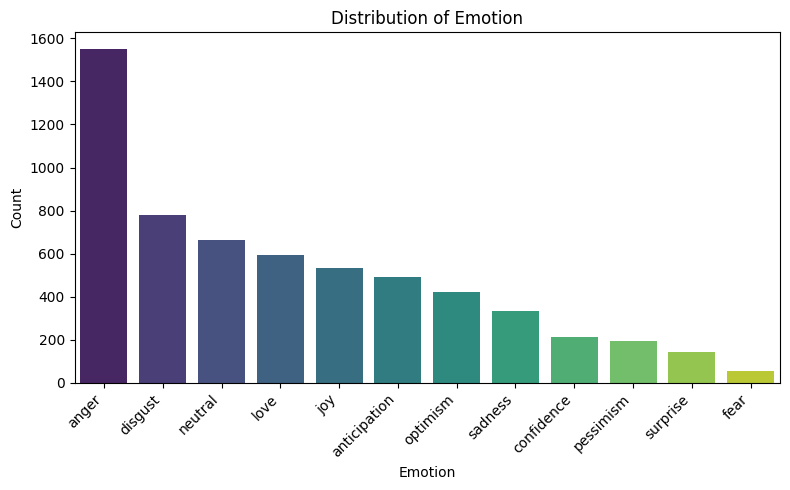


--- Offensive ---
Offensive
no     4216
yes    1744
Name: count, dtype: int64
Offensive
no     70.74
yes    29.26
Name: proportion, dtype: float64


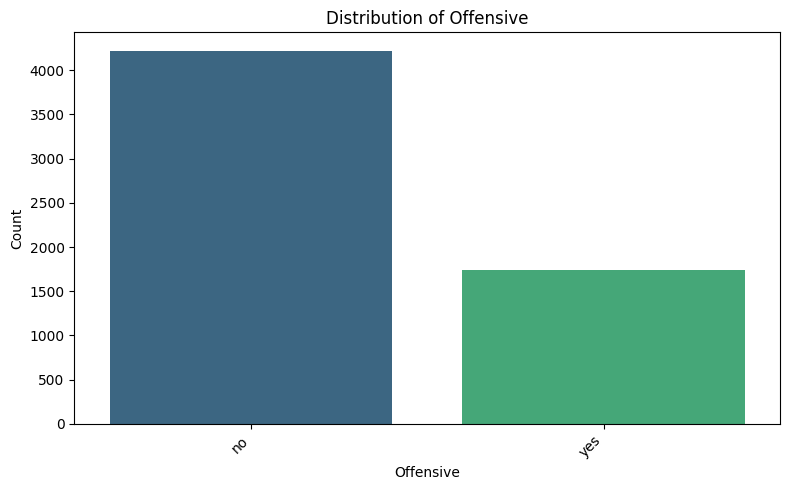


--- Hate ---
Hate
NaN         4216
not_hate    1441
hate         303
Name: count, dtype: int64
Hate
NaN         70.74
not_hate    24.18
hate         5.08
Name: proportion, dtype: float64


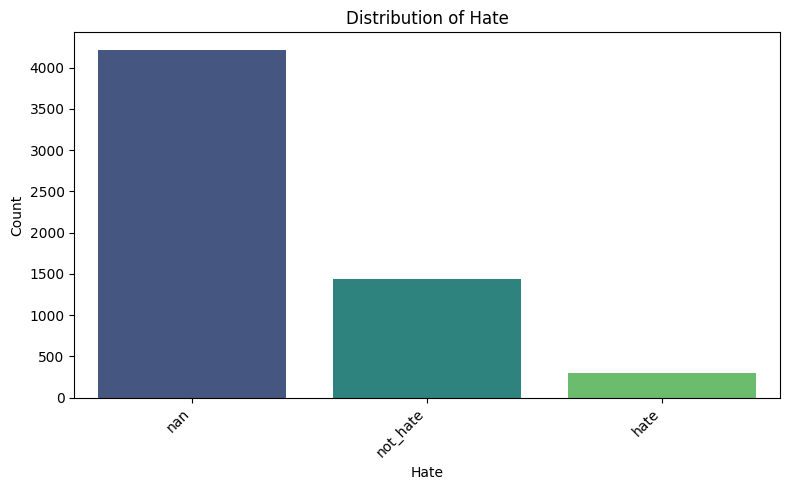

In [5]:
for col in ["Emotion", "Offensive", "Hate"]:
    counts = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(dropna=False, normalize=True) * 100

    print(f"\n--- {col} ---")
    print(counts)
    print(pct.round(2))

    plt.figure(figsize=(8, 5))
    sns.barplot(x=counts.index.astype(str), y=counts.values,
                hue=counts.index.astype(str), palette="viridis", legend=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 2. Preprocessing (single pass — needed before n-grams and embeddings)

In [6]:
model_name = "aubmindlab/bert-base-arabertv02-twitter"
preprocessor = ArabertPreprocessor(model_name=model_name)

def preprocess_text(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\S+', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = "".join(c for c in text if unicodedata.category(c) != "So")
    text = preprocessor.preprocess(text)
    return text

df["clean_text"] = df["text"].apply(preprocess_text)
df[["text", "clean_text"]].head(5)

,text,clean_text
0,أحد التجار الشباب العمانيين يقول للاسف لما يكو...,أحد التجار الشباب العمانيين يقول للاسف لما يكو...
1,@JALHARBISKY مجموعه القدرة الجنسيه👍<LF> <LF>بد...,مجموعه القدرة الجنسيه بديل الفياجرا والسنافي ز...
2,@rwn4o حبيبييي والله اكثثثرر يارب امين🥺♥️♥️,حبيبي والله اكثرر يارب امين
3,#وصال_دوت_FM<LF>مع سميرة الفطيسية @Samira_Alfu...,# وصال _ دوت _ FM مع سميرة الفطيسية أمل الشكيل...
4,من ينتزع ارواح اطفالنا من أجسادها بكل وحشية عل...,من ينتزع ارواح اطفالنا من أجسادها بكل وحشية عل...


## 3. EDA — N-gram Analysis per Category

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Columns in your dataset:
['id', 'text', 'Emotion', 'Offensive', 'Hate', 'clean_text']

All required columns were found successfully!


TOP 20 UNIGRAMS


/tmp/ipykernel_7848/428824217.py:557: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


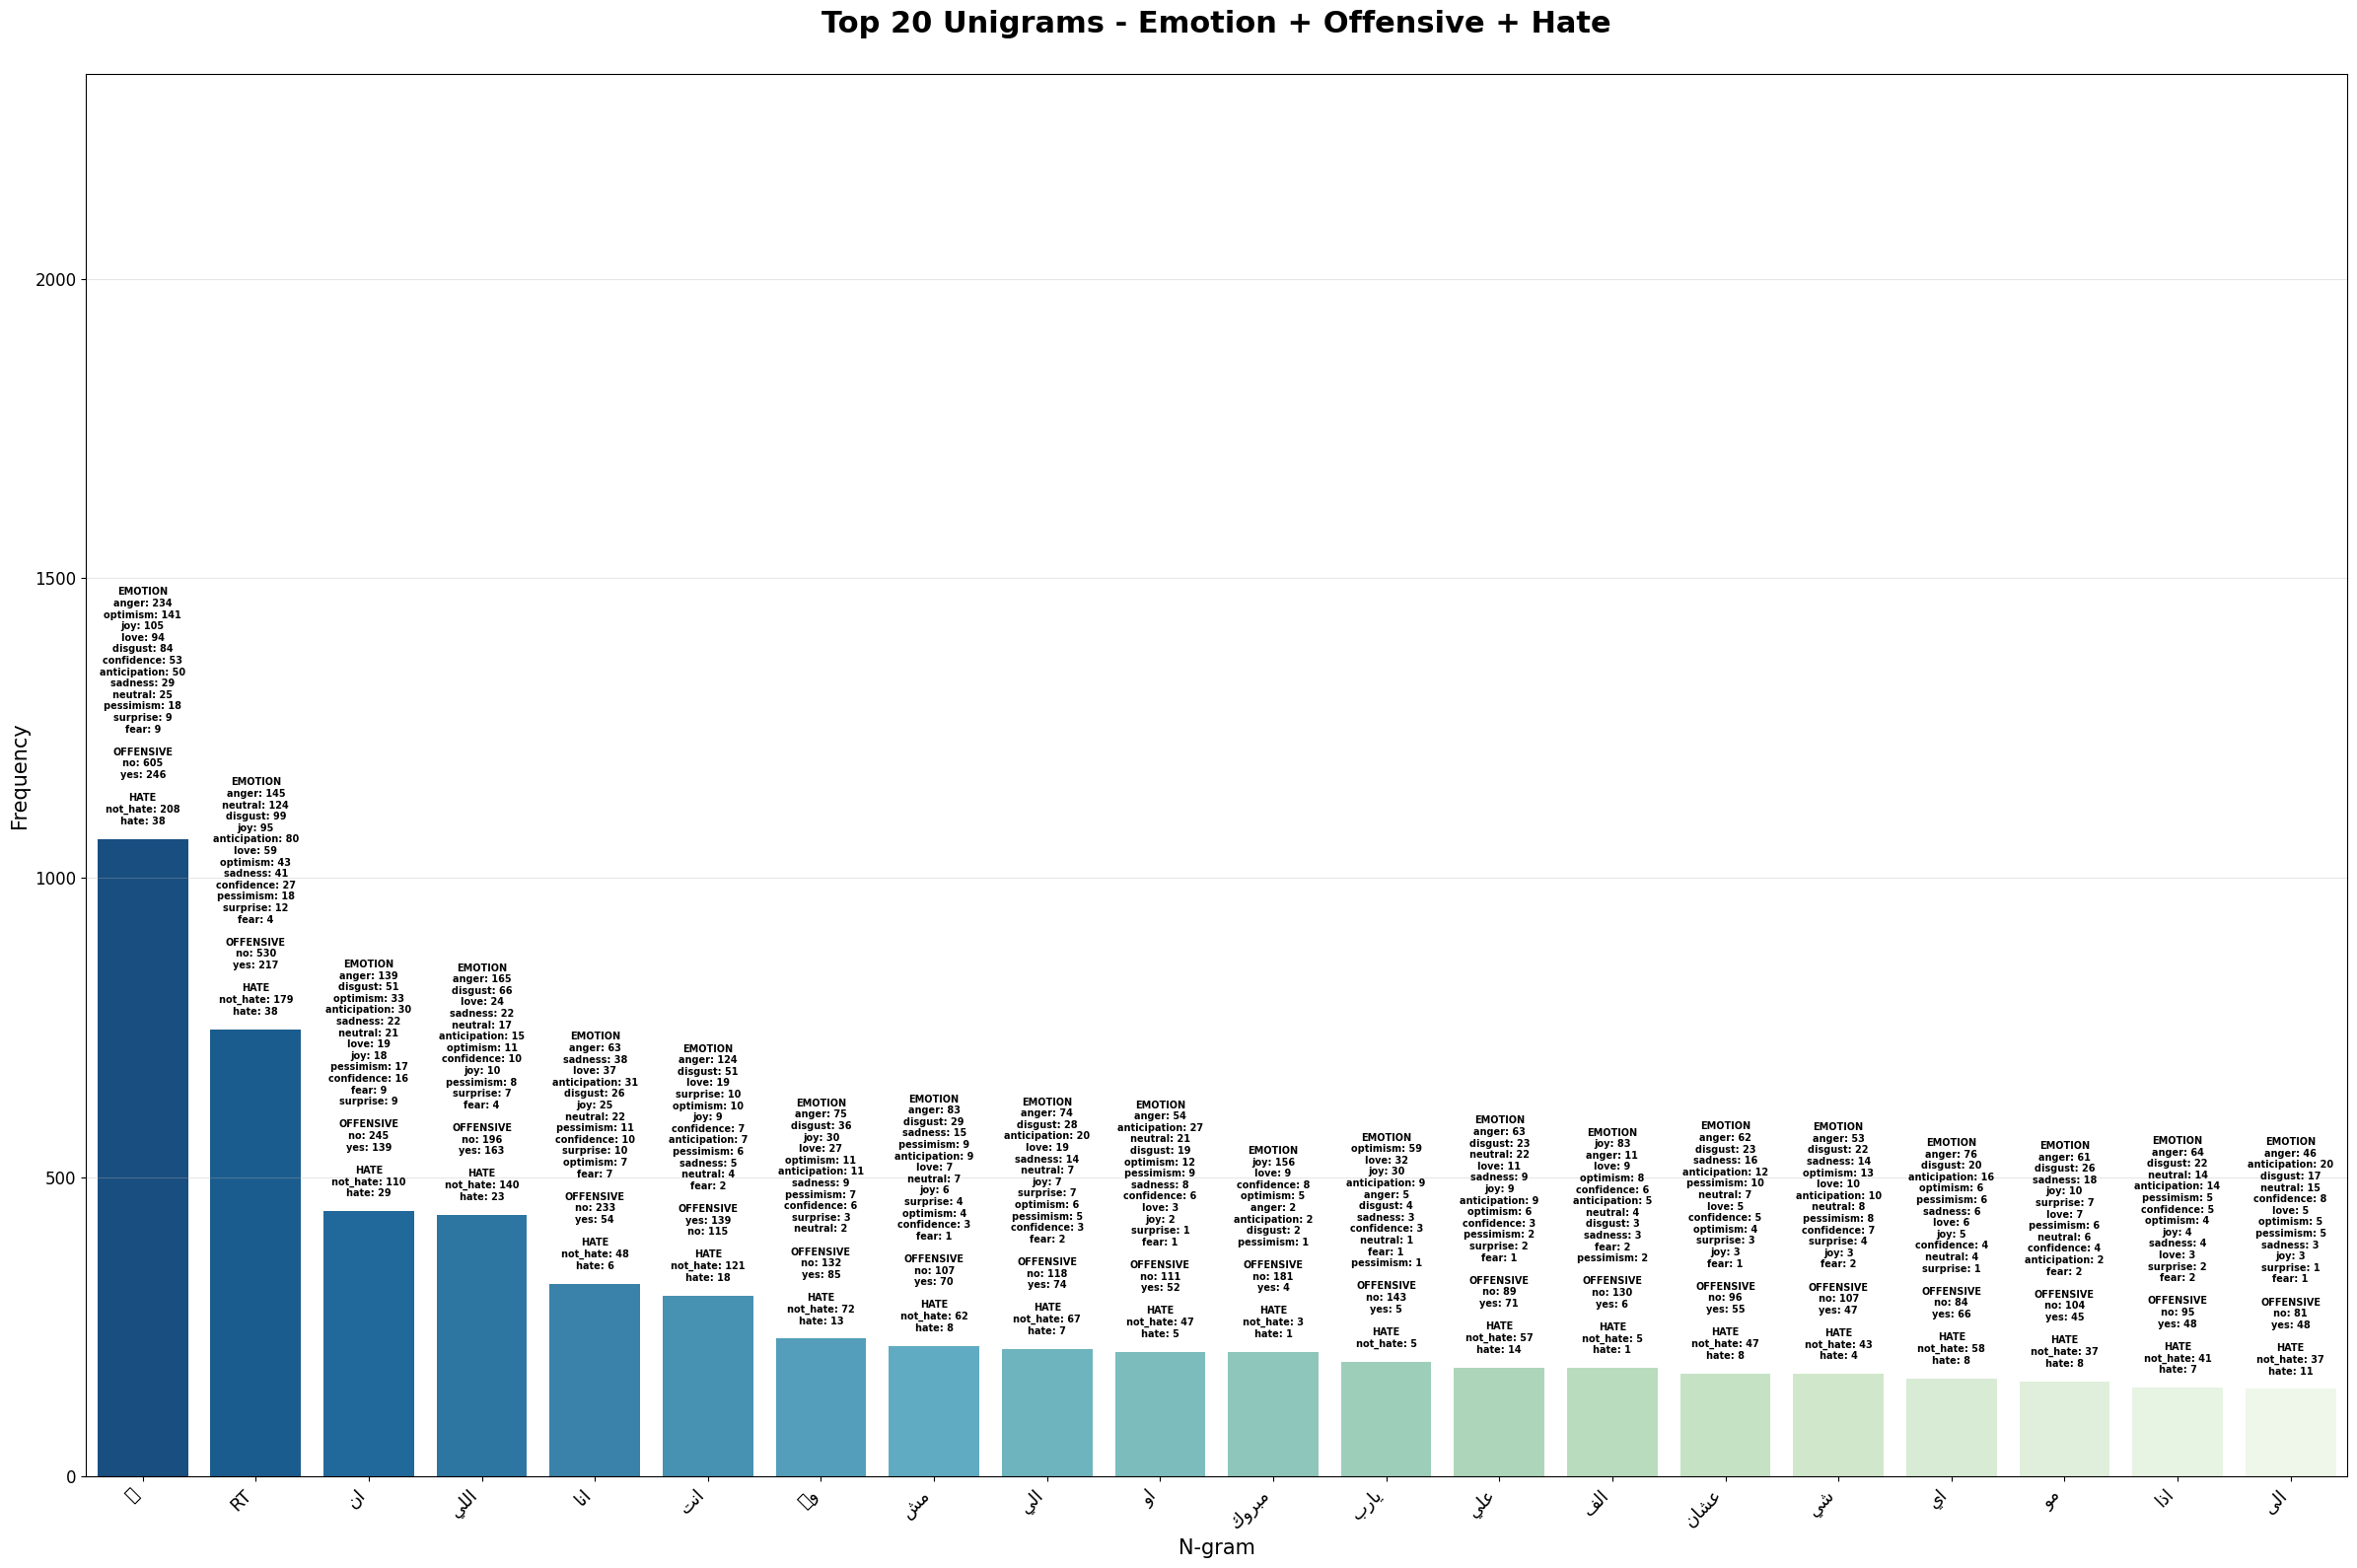



TOP 20 BIGRAMS


/tmp/ipykernel_7848/428824217.py:557: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


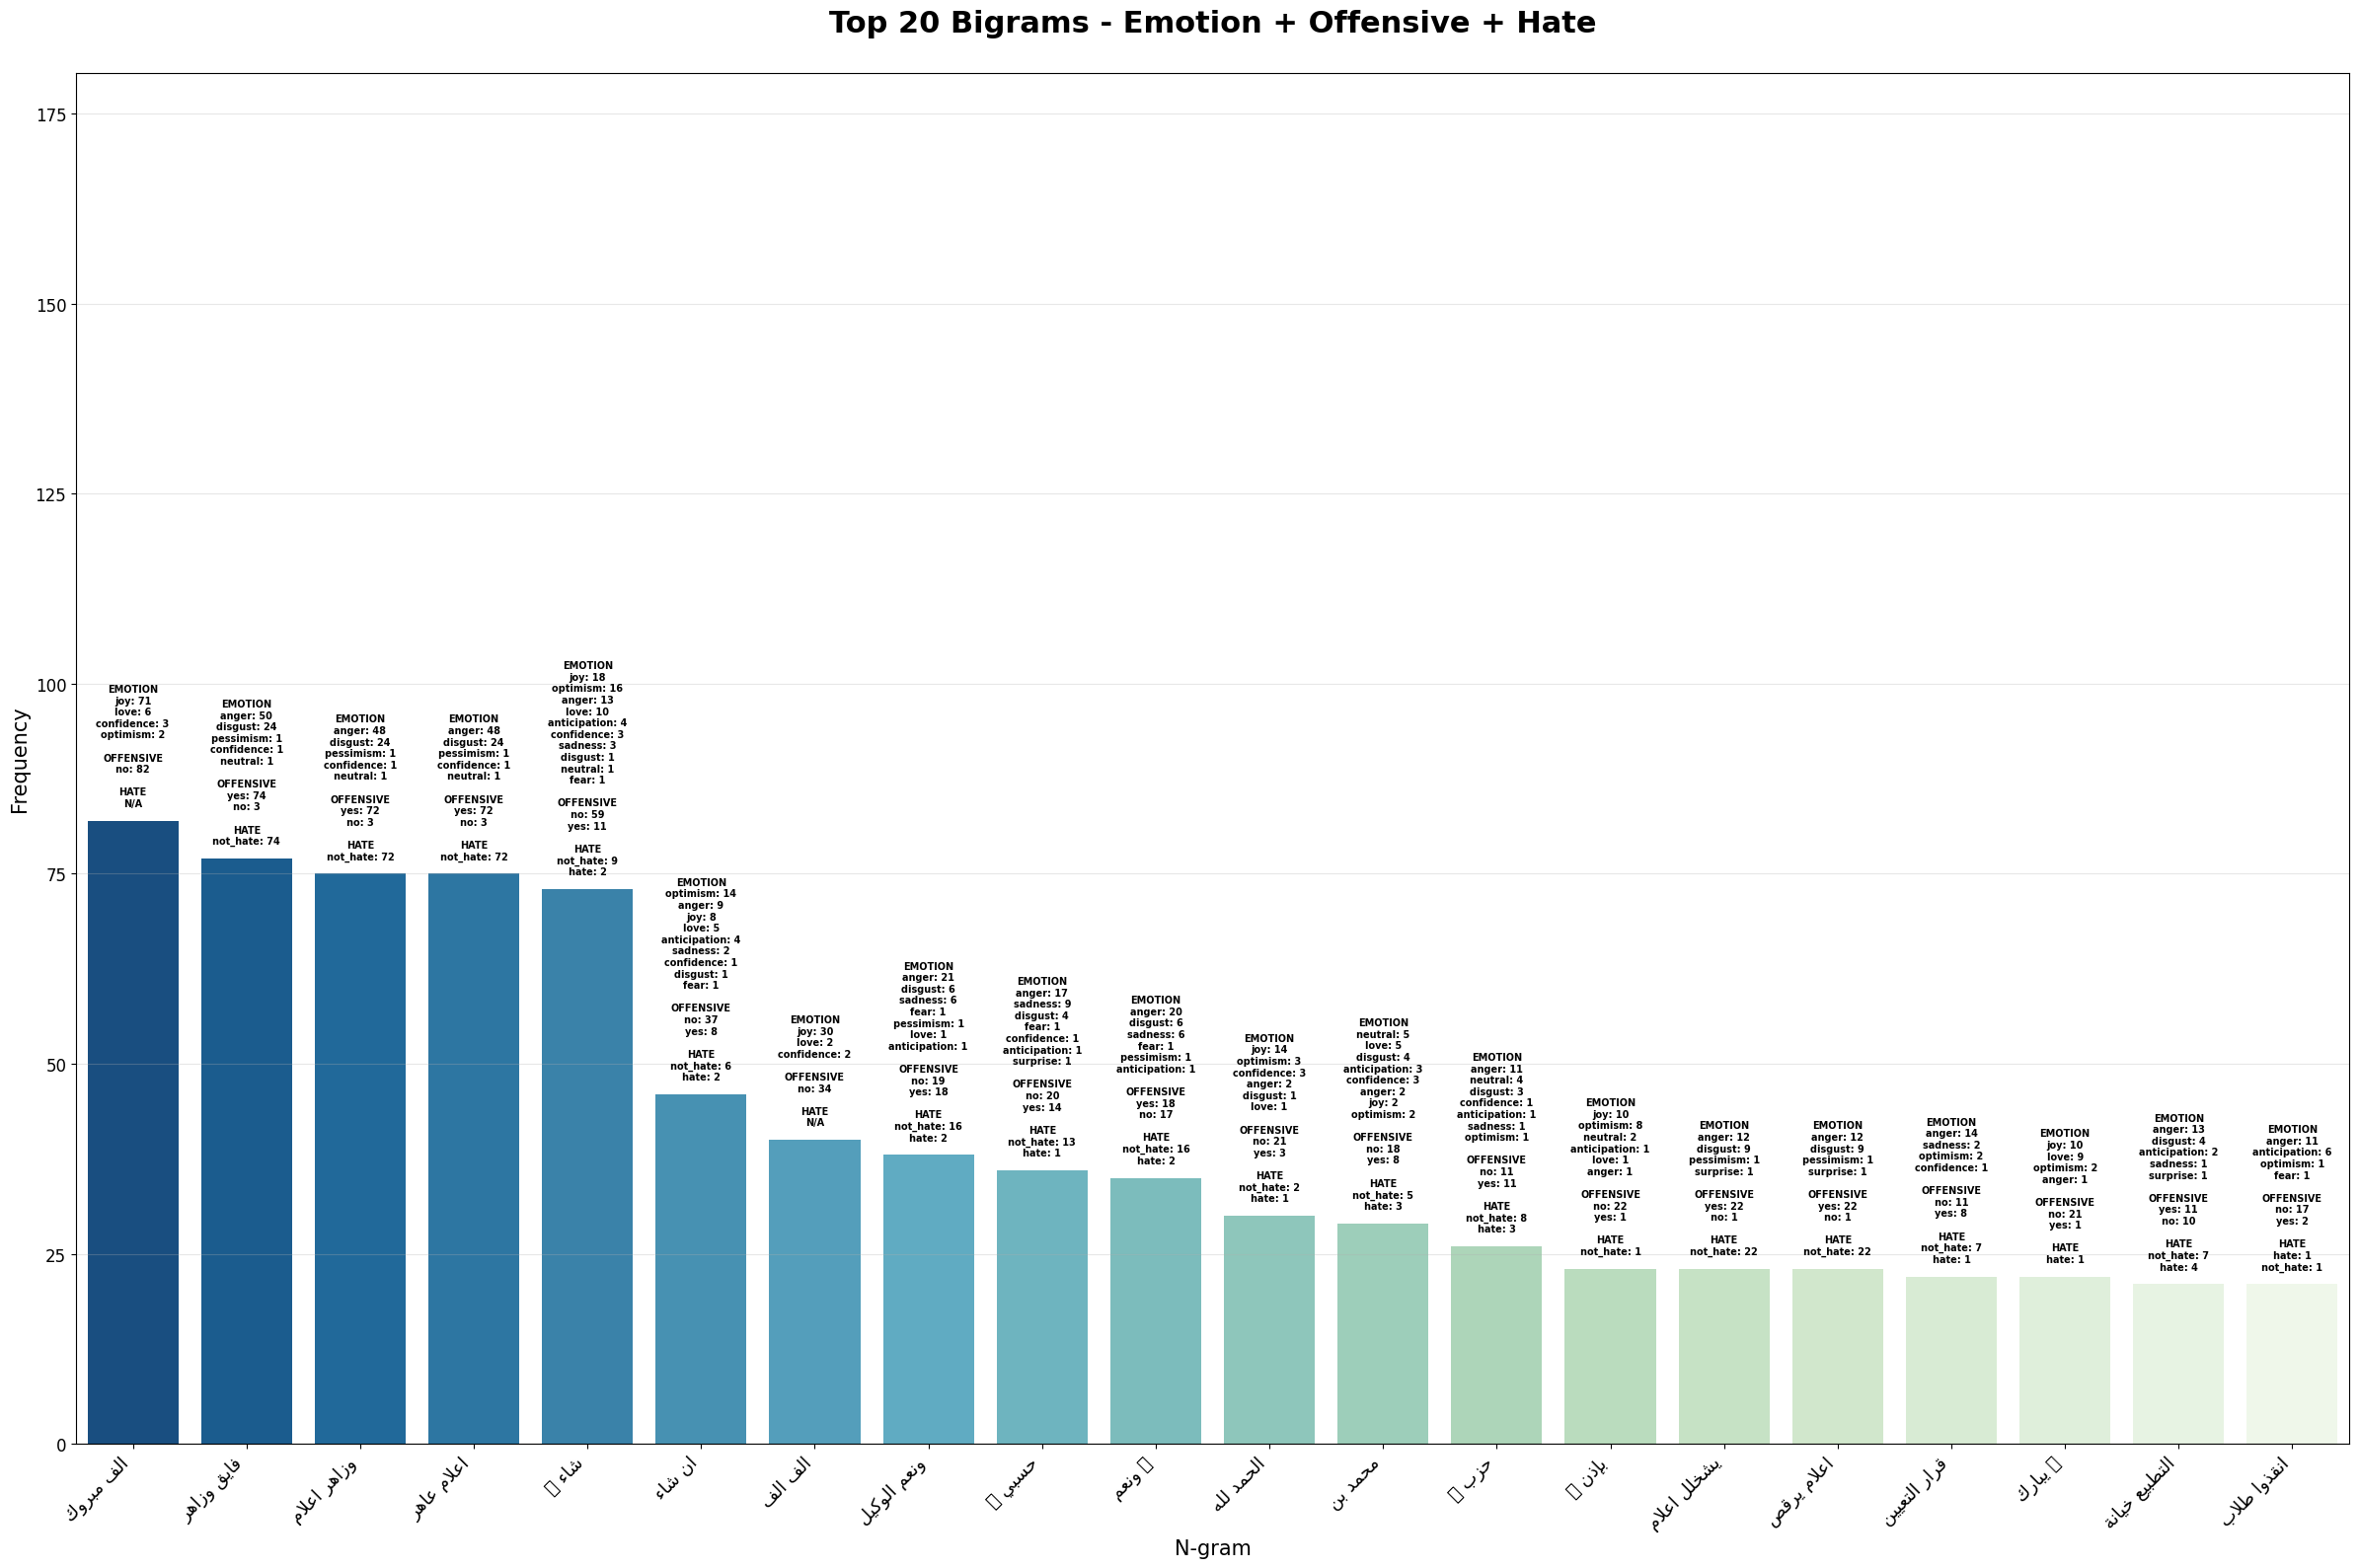



TOP 20 TRIGRAMS


/tmp/ipykernel_7848/428824217.py:557: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


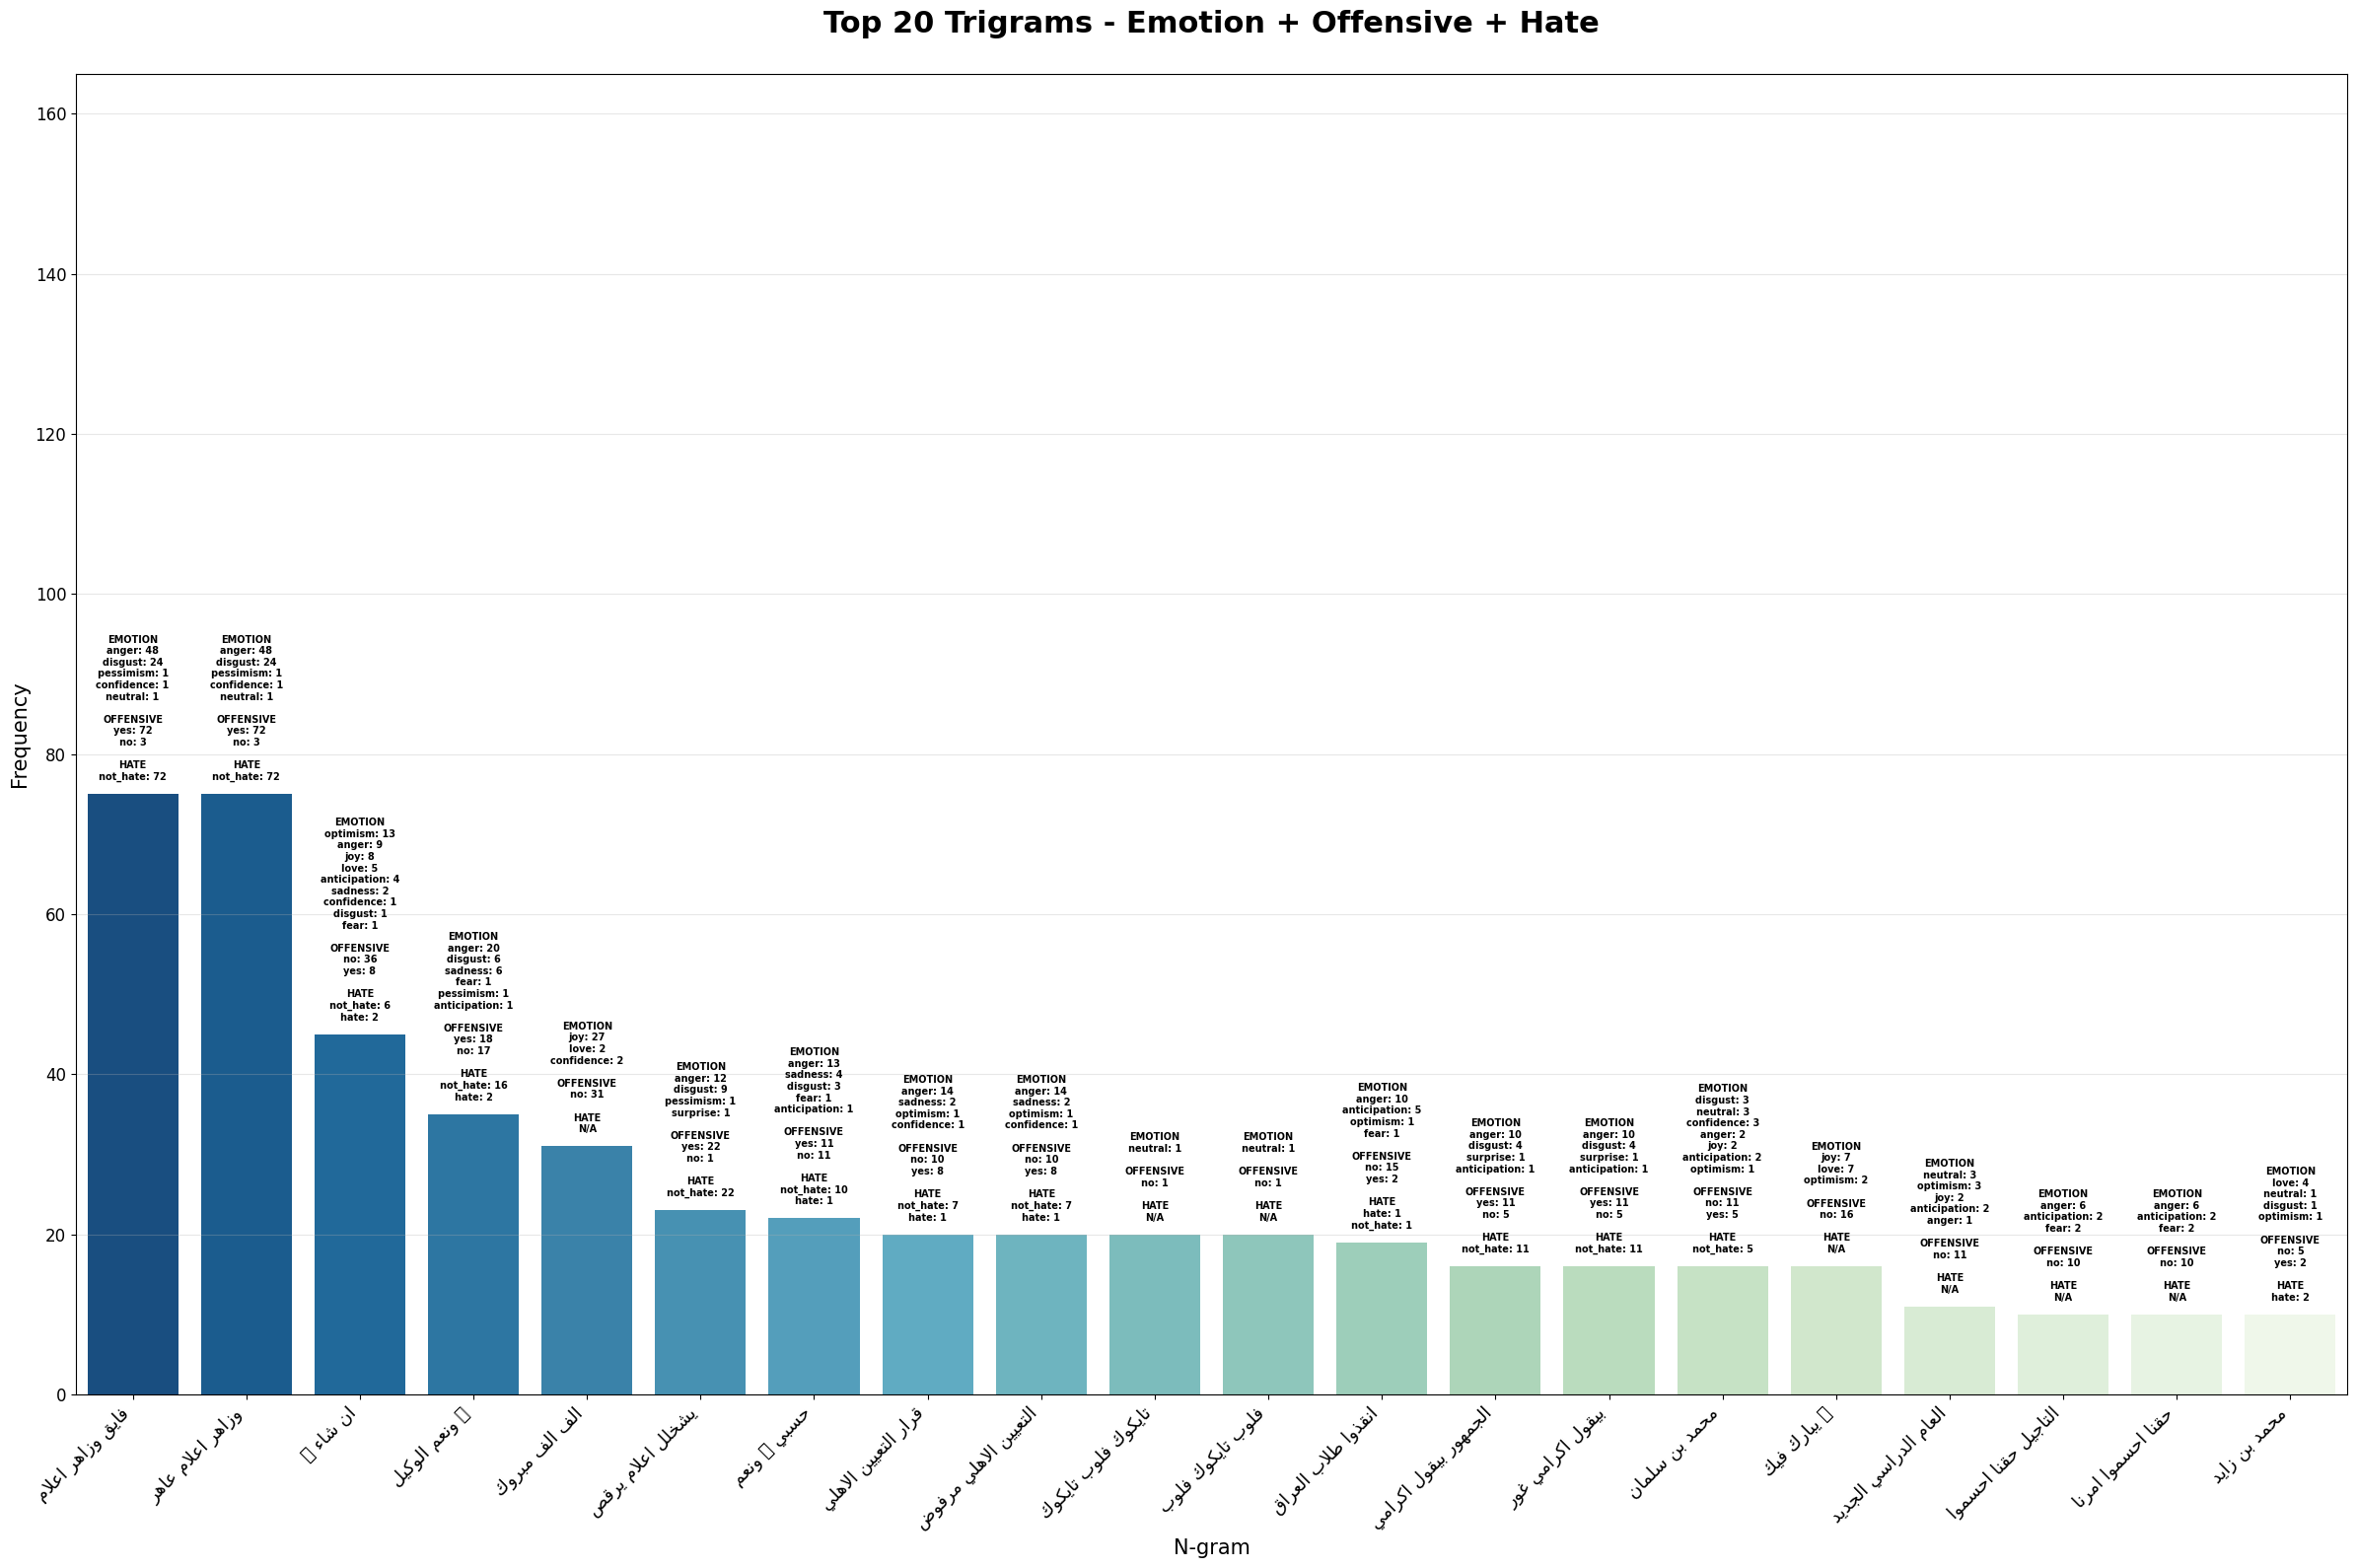

In [10]:
# ============================================================
# 1. Install libraries
# ============================================================

!pip install nltk wordcloud arabic-reshaper python-bidi seaborn pandas


# ============================================================
# 2. Imports
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter, defaultdict

import arabic_reshaper
from bidi.algorithm import get_display


# ============================================================
# 3. Download NLTK resources
# ============================================================

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

arabic_stopwords = set(
    stopwords.words('arabic')
)


# ============================================================
# 4. Display DataFrame columns
# ============================================================

print("Columns in your dataset:")
print(df.columns.tolist())


# ============================================================
# 5. Column names
# ============================================================

TEXT_COLUMN = 'clean_text'

EMOTION_COLUMN = 'Emotion'

OFFENSIVE_COLUMN = 'Offensive'

HATE_COLUMN = 'Hate'


# ============================================================
# 6. Check columns
# ============================================================

required_columns = [
    TEXT_COLUMN,
    EMOTION_COLUMN,
    OFFENSIVE_COLUMN,
    HATE_COLUMN
]

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_columns:

    print("\nERROR!")
    print("The following columns were not found:")
    print(missing_columns)

    print("\nAvailable columns:")
    print(df.columns.tolist())

    raise ValueError(
        "Please check the column names above."
    )

else:

    print(
        "\nAll required columns were found successfully!"
    )


# ============================================================
# 7. Arabic tokenization
# ============================================================

def tokenize_arabic(text):

    if pd.isna(text):
        return []

    text = str(text)

    words = nltk.word_tokenize(text)

    filtered_words = [
        word
        for word in words
        if word.isalpha()
        and word not in arabic_stopwords
    ]

    return filtered_words


# ============================================================
# 8. Generate n-grams
# ============================================================

def generate_ngrams(
    text_list,
    n=1,
    num_top_ngrams=20
):

    all_ngrams = []

    for text in text_list:

        words = tokenize_arabic(text)

        current_ngrams = list(
            ngrams(words, n)
        )

        all_ngrams.extend(
            current_ngrams
        )

    counts = Counter(
        all_ngrams
    )

    return counts.most_common(
        num_top_ngrams
    )


# ============================================================
# 9. Find class distribution for each n-gram
# ============================================================

def get_ngram_label_info(
    df,
    top_ngrams,
    n
):

    emotion_info = defaultdict(Counter)

    offensive_info = defaultdict(Counter)

    hate_info = defaultdict(Counter)


    # --------------------------------------------------------
    # Process every row
    # --------------------------------------------------------

    for _, row in df.iterrows():

        text = row[TEXT_COLUMN]

        if pd.isna(text):
            continue

        words = tokenize_arabic(text)

        # Use set so that an n-gram is counted once
        # per sentence rather than multiple times
        row_ngrams = set(
            ngrams(words, n)
        )


        # ----------------------------------------------------
        # Emotion
        # ----------------------------------------------------

        emotion = row[EMOTION_COLUMN]

        if not pd.isna(emotion):

            for ng in row_ngrams:

                emotion_info[ng][
                    str(emotion)
                ] += 1


        # ----------------------------------------------------
        # Offensive
        # ----------------------------------------------------

        offensive = row[OFFENSIVE_COLUMN]

        if not pd.isna(offensive):

            for ng in row_ngrams:

                offensive_info[ng][
                    str(offensive)
                ] += 1


        # ----------------------------------------------------
        # Hate
        # ----------------------------------------------------

        hate = row[HATE_COLUMN]

        if not pd.isna(hate):

            for ng in row_ngrams:

                hate_info[ng][
                    str(hate)
                ] += 1


    return (
        emotion_info,
        offensive_info,
        hate_info
    )


# ============================================================
# 10. Create readable annotation
# ============================================================

def get_annotation(
    ngram,
    emotion_info,
    offensive_info,
    hate_info
):

    # --------------------------------------------------------
    # Emotion
    # --------------------------------------------------------

    emotions = emotion_info.get(
        ngram,
        {}
    )

    if emotions:

        # Show all emotion classes vertically
        emotion_lines = [
            f"{label}: {count}"
            for label, count
            in emotions.most_common()
        ]

        emotion_text = (
            "EMOTION\n"
            + "\n".join(emotion_lines)
        )

    else:

        emotion_text = "EMOTION\nN/A"


    # --------------------------------------------------------
    # Offensive
    # --------------------------------------------------------

    offensive = offensive_info.get(
        ngram,
        {}
    )

    if offensive:

        offensive_lines = [
            f"{label}: {count}"
            for label, count
            in offensive.most_common()
        ]

        offensive_text = (
            "OFFENSIVE\n"
            + "\n".join(offensive_lines)
        )

    else:

        offensive_text = "OFFENSIVE\nN/A"


    # --------------------------------------------------------
    # Hate
    # --------------------------------------------------------

    hate = hate_info.get(
        ngram,
        {}
    )

    if hate:

        hate_lines = [
            f"{label}: {count}"
            for label, count
            in hate.most_common()
        ]

        hate_text = (
            "HATE\n"
            + "\n".join(hate_lines)
        )

    else:

        hate_text = "HATE\nN/A"


    # --------------------------------------------------------
    # Combine
    # --------------------------------------------------------

    return (
        emotion_text
        + "\n\n"
        + offensive_text
        + "\n\n"
        + hate_text
    )


# ============================================================
# 11. Plot function
# ============================================================

def plot_ngrams(
    ngrams_data,
    emotion_info,
    offensive_info,
    hate_info,
    title
):

    if not ngrams_data:

        print(
            "No n-grams found."
        )

        return


    # --------------------------------------------------------
    # Prepare Arabic labels
    # --------------------------------------------------------

    words = []

    for ngram, count in ngrams_data:

        arabic_word = ' '.join(
            ngram
        )

        reshaped = arabic_reshaper.reshape(
            arabic_word
        )

        bidi_word = get_display(
            reshaped
        )

        words.append(
            bidi_word
        )


    # --------------------------------------------------------
    # Frequencies
    # --------------------------------------------------------

    counts = [
        count
        for ngram, count
        in ngrams_data
    ]


    # --------------------------------------------------------
    # Create large figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(24, 16)
    )


    # --------------------------------------------------------
    # Plot bars
    # --------------------------------------------------------

    bars = sns.barplot(
        x=words,
        y=counts,
        hue=words,
        legend=False,
        palette='GnBu_r',
        ax=ax
    )


    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=22,
        fontweight='bold',
        pad=30
    )


    ax.set_xlabel(
        'N-gram',
        fontsize=15
    )


    ax.set_ylabel(
        'Frequency',
        fontsize=15
    )


    # --------------------------------------------------------
    # X labels
    # --------------------------------------------------------

    ax.tick_params(
        axis='x',
        labelsize=13
    )

    ax.tick_params(
        axis='y',
        labelsize=12
    )


    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha='right'
    )


    # --------------------------------------------------------
    # Maximum bar height
    # --------------------------------------------------------

    max_count = max(
        counts
    )


    # ========================================================
    # Add annotations above bars
    # ========================================================

    for bar, (ngram, count) in zip(
        bars.patches,
        ngrams_data
    ):

        # Get annotation
        annotation = get_annotation(
            ngram,
            emotion_info,
            offensive_info,
            hate_info
        )


        # Position
        x_position = (
            bar.get_x()
            + bar.get_width() / 2
        )


        y_position = (
            bar.get_height()
            + max_count * 0.02
        )


        # ----------------------------------------------------
        # Write annotation
        # ----------------------------------------------------

        ax.text(
            x_position,
            y_position,
            annotation,

            ha='center',
            va='bottom',

            fontsize=7,

            fontweight='bold',

            linespacing=1.2
        )


    # ========================================================
    # Give annotation enough space
    # ========================================================

    ax.set_ylim(
        0,
        max_count * 2.2
    )


    # ========================================================
    # Horizontal grid
    # ========================================================

    ax.grid(
        axis='y',
        alpha=0.3
    )


    # ========================================================
    # Layout
    # ========================================================

    plt.tight_layout()

    plt.show()


# ============================================================
# 12. UNIGRAMS
# ============================================================

print("\n")
print("=" * 80)
print("TOP 20 UNIGRAMS")
print("=" * 80)


unigrams = generate_ngrams(
    df[TEXT_COLUMN],
    n=1,
    num_top_ngrams=20
)


(
    unigram_emotions,
    unigram_offensive,
    unigram_hate
) = get_ngram_label_info(
    df,
    unigrams,
    n=1
)


plot_ngrams(
    unigrams,
    unigram_emotions,
    unigram_offensive,
    unigram_hate,
    'Top 20 Unigrams - Emotion + Offensive + Hate'
)


# ============================================================
# 13. BIGRAMS
# ============================================================

print("\n")
print("=" * 80)
print("TOP 20 BIGRAMS")
print("=" * 80)


bigrams = generate_ngrams(
    df[TEXT_COLUMN],
    n=2,
    num_top_ngrams=20
)


(
    bigram_emotions,
    bigram_offensive,
    bigram_hate
) = get_ngram_label_info(
    df,
    bigrams,
    n=2
)


plot_ngrams(
    bigrams,
    bigram_emotions,
    bigram_offensive,
    bigram_hate,
    'Top 20 Bigrams - Emotion + Offensive + Hate'
)


# ============================================================
# 14. TRIGRAMS
# ============================================================

print("\n")
print("=" * 80)
print("TOP 20 TRIGRAMS")
print("=" * 80)


trigrams = generate_ngrams(
    df[TEXT_COLUMN],
    n=3,
    num_top_ngrams=20
)


(
    trigram_emotions,
    trigram_offensive,
    trigram_hate
) = get_ngram_label_info(
    df,
    trigrams,
    n=3
)


plot_ngrams(
    trigrams,
    trigram_emotions,
    trigram_offensive,
    trigram_hate,
    'Top 20 Trigrams - Emotion + Offensive + Hate'
)

## 4. Baseline Model — AraBERT Embeddings + Logistic Regression

Embeds the full dataset (batched, mean-pooled) once, then trains a simple Logistic Regression per label as the baseline to beat.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

def embed_texts(texts, batch_size=32, max_length=64):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(batch, padding="max_length", truncation=True,
                            max_length=max_length, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        pooled = mean_pool(outputs.last_hidden_state, inputs["attention_mask"])
        all_embeddings.append(pooled.cpu().numpy())
        if i % (batch_size * 10) == 0:
            print(f"Embedded {i}/{len(texts)}")
    return np.vstack(all_embeddings)

X = embed_texts(df["clean_text"].tolist())
print("Embedding matrix shape:", X.shape)

config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/476 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/751k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  541MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02-twitter
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Embedded 0/5960
Embedded 320/5960
Embedded 640/5960
Embedded 960/5960
Embedded 1280/5960
Embedded 1600/5960
Embedded 1920/5960
Embedded 2240/5960
Embedded 2560/5960
Embedded 2880/5960
Embedded 3200/5960
Embedded 3520/5960
Embedded 3840/5960
Embedded 4160/5960
Embedded 4480/5960
Embedded 4800/5960
Embedded 5120/5960
Embedded 5440/5960
Embedded 5760/5960
Embedding matrix shape: (5960, 768)



===== Baseline — Emotion =====
Accuracy: 0.4664429530201342
Macro F1: 0.375652027942394
              precision    recall  f1-score   support

       anger       0.64      0.51      0.57       310
anticipation       0.32      0.38      0.35        98
  confidence       0.19      0.29      0.23        42
     disgust       0.40      0.43      0.41       155
        fear       0.11      0.09      0.10        11
         joy       0.58      0.49      0.53       106
        love       0.58      0.66      0.61       119
     neutral       0.61      0.58      0.59       132
    optimism       0.44      0.42      0.43        84
   pessimism       0.11      0.13      0.12        39
     sadness       0.38      0.45      0.41        67
    surprise       0.14      0.17      0.16        29

    accuracy                           0.47      1192
   macro avg       0.37      0.38      0.38      1192
weighted avg       0.49      0.47      0.47      1192



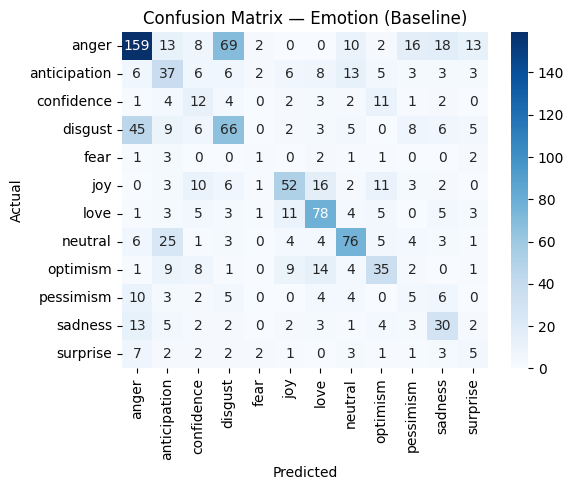


===== Baseline — Offensive =====
Accuracy: 0.8296979865771812
Macro F1: 0.8069724940430749
              precision    recall  f1-score   support

          no       0.92      0.83      0.87       843
         yes       0.67      0.83      0.74       349

    accuracy                           0.83      1192
   macro avg       0.80      0.83      0.81      1192
weighted avg       0.85      0.83      0.83      1192



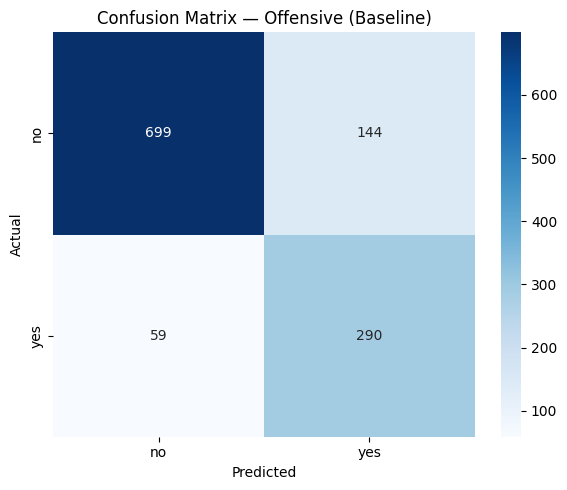


===== Baseline — Hate =====
Accuracy: 0.7707736389684814
Macro F1: 0.6347079757169771
              precision    recall  f1-score   support

        hate       0.37      0.46      0.41        61
    not_hate       0.88      0.84      0.86       288

    accuracy                           0.77       349
   macro avg       0.63      0.65      0.63       349
weighted avg       0.79      0.77      0.78       349



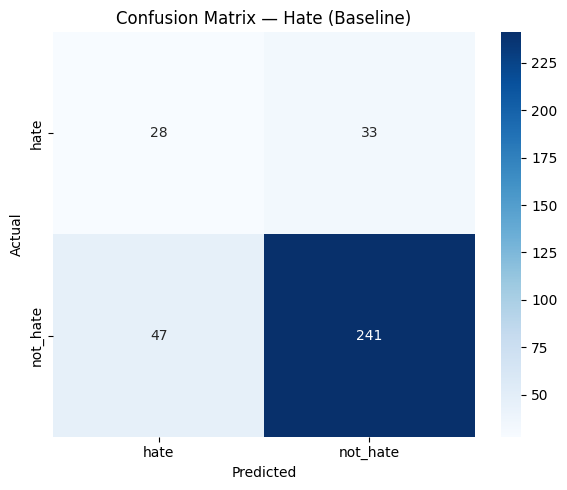

In [11]:
def train_baseline(X, y, label_name):
    mask = y.notna()
    X_use, y_use = X[mask.values], y[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X_use, y_use, test_size=0.2, random_state=42, stratify=y_use
    )

    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    print(f"\n===== Baseline — {label_name} =====")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Macro F1:", f1_score(y_test, preds, average="macro"))
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds, labels=clf.classes_)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=clf.classes_, yticklabels=clf.classes_)
    plt.title(f"Confusion Matrix — {label_name} (Baseline)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return clf

clf_emotion   = train_baseline(X, df["Emotion"],   "Emotion")
clf_offensive = train_baseline(X, df["Offensive"], "Offensive")
clf_hate      = train_baseline(X, df["Hate"],      "Hate")